In [4]:

# Tool - 1 
from langchain_community.tools import DuckDuckGoSearchRun
search_tool= DuckDuckGoSearchRun(description="search live data from internet")
search_tool.invoke("Who is MS Dhoni")

"M.S.Dhoni, the iconic Indian cricketer and former captain of the national team, showcased his exceptional leadership skills and remarkable batting prowess to guide India to numerous victories in international cricket. MSDhoniBiography includesDhoni'sstats, career acheivements, controversies, Awards recieved along with his car and bike collection details. IPL 2026:MSDhoniisset to play another season of the IPL, now the question is - will he play IPL 2027? By the time the next IPL season comes around,Dhoniwould be 45. While fans have been making speculations over it over the past decade,Dhonistill continues to wear the yellow and play for CSK ... A captain, batter and wicket-keeper par excellence,MSDhonihas become one of the latest inductees into the ICC Hall of Fame. Here's everything to know about Indian cricketerMSDhonicareer, stats, wife, family, social media, net worth, and his performance in international cricket and IPL."

In [1]:
# Tool - 2

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

api_wrapper = WikipediaAPIWrapper(
    top_k_results=3,
    doc_content_chars_max=4000
)

wikipedia_tool = WikipediaQueryRun(api_wrapper=api_wrapper, description="search data from Wikipedia")

result = wikipedia_tool.invoke("tell me about Virat Kohli")
print(result)

Page: Anushka Sharma
Summary: Anushka Sharma (pronounced [əˈnʊʃka ˈʃərma]; born 1 May 1988) is a former Indian actress & producer who works in Hindi films. She has won many awards including Filmfare Awards and IIFA Awards. Sharma has appeared in Forbes India's Celebrity 100 in the 2010s and was featured by Forbes Asia in their 30 Under 30 list of 2018.
Born in Ayodhya and raised in Bangalore, Sharma had her first modelling assignment for the fashion designer Wendell Rodricks in 2007 and later moved to Mumbai to pursue a full-time career as a model. She made her acting debut opposite Shah Rukh Khan in the top-grossing romantic film Rab Ne Bana Di Jodi (2008) and rose to prominence with starring roles in Yash Raj Films' romances Band Baaja Baaraat (2010) and Jab Tak Hai Jaan (2012), winning the Filmfare Award for Best Supporting Actress for the latter. Sharma went on to earn praise for playing strong-willed women in the crime thriller NH10 (2015), and the dramas Dil Dhadakne Do (2015), A

In [ ]:
# Tool -3

from langchain.tools import tool

@tool
def enterprise_tool(query:str)-> str:
    """ This tool is to send emails """
    return "Email sent"


In [ ]:
tool_kit = [search_tool, wikipedia_tool, enterprise_tool ]

In [6]:
tool_kit

[DuckDuckGoSearchRun(description='search live data from internet', api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(description='search data from Wikipedia', api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\Dell\\AI_projects\\GenAI\\Langchain_uv_demo\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='enterprose_tool', description='This tool is to send emails', args_schema=<class 'langchain_core.utils.pydantic.enterprose_tool'>, func=<function enterprose_tool at 0x0000023EE7D6E7A0>)]

# **React Agent**

In [9]:
from langchain.agents import create_agent
from  langchain_openai import ChatOpenAI
from langchain_openai.embeddings.base import MAX_TOKENS_PER_REQUEST

model = ChatOpenAI(
    model="gpt-5-mini",
    temperature=0,
    max_tokens = 1000,
    timeout=30
)

agent = create_agent(model, tools=tool_kit)

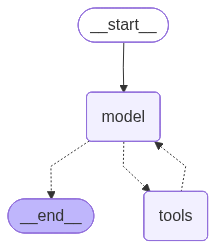

In [11]:
agent

# **React Agent invoke with streams**

In [17]:
query  ="Give me the lated news about Chennai Super Kings"

events = agent.stream(
    {"messages":[("user", query)]},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Give me the lated news about Chennai Super Kings
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_CGdMP8vAt5x4cBM7ZTtTu2An)
 Call ID: call_CGdMP8vAt5x4cBM7ZTtTu2An
  Args:
    query: Chennai Super Kings latest news
  wikipedia (call_KOejDesdILdhVSaz1z48KNr0)
 Call ID: call_KOejDesdILdhVSaz1z48KNr0
  Args:
    query: Chennai Super Kings
================================= Tool Message =================================
Name: wikipedia

Page: Chennai Super Kings
Summary: The Chennai Super Kings, also known as CSK, are a professional Twenty20 cricket team based in Chennai, Tamil Nadu, that competes in the Indian Premier League (IPL). The team was one of the eight debut franchises when the league was established in 2008. The team plays its home matches at the M. A. Chidambaram Stadium and is owned by Chennai Super Kings Cricket.
The Super King

# **Manually Binding the LLM**

In [19]:
llm = ChatOpenAI(model='gpt-5-mini', temperature=0)

llm_binded= llm.bind_tools(tool_kit)

In [20]:
resp = llm_binded.invoke("Whahat is the current news abot IPL 2026")

In [21]:
resp

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_tokens': 194, 'total_tokens': 323, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DNGrkLjt6Ehg3js3yb4EtkL4DSljd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d24ca-8a8d-79a3-8d3d-10babc75c51c-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'IPL 2026 news'}, 'id': 'call_FFRPcSqnWUX2Zkt6o5k6EPaS', 'type': 'tool_call'}, {'name': 'wikipedia', 'args': {'query': 'Indian Premier League 2026'}, 'id': 'call_60aaJNQHBWybOEP4HSrTA2pI', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 194, 'output_tokens': 129, 'to